# 02 — Feature Distributions

Distribution analysis of the engineered behavioral features from `data/processed/features.parquet`.

> **Prerequisite:** run `python -m pipeline.features.run` (or `dvc repro features`) first.

**Setup — imports & configuration.**
Loads the standard analysis stack (`pandas`, `numpy`, `matplotlib`, `seaborn`) and adds the project root to `sys.path` so `pipeline.features.run.FEATURE_COLS` (the 18 engineered feature names) can be imported. Sets `ROOT` and `FIGURES` paths and configures the seaborn plot theme.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from pipeline.features.run import FEATURE_COLS

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

**Data loading — feature windows.**
Reads `data/processed/features.parquet` produced by the feature-engineering pipeline. Each row is one time window from a recording session. Prints shape and unique players.

**Findings:** Shape `(3, 26)` — only **3 windows** from **1 player** (hydra, single Arc Raiders session). The distributions below reflect a single recording session; they will become population-meaningful once sessions from all 4+ players are recorded.

In [2]:
features = pd.read_parquet(ROOT / "data/processed/features.parquet")
print(f"Features shape: {features.shape}")
print(f"Players       : {sorted(features['player'].unique())}")
print(f"Windows       : {len(features)}")
features.head()

Features shape: (3, 26)
Players       : ['hydra']
Windows       : 3


,session_id,window_idx,player,game,sensitivity,dpi,recorded_at,duration_ms,speed_mean,speed_std,...,hold_std,iki_mean,iki_std,burst_rate,wasd_rhythm,event_rate,mouse_key_ratio,active_time_pct,scroll_count,scroll_direction_ratio
0,97e57c85,0,hydra,arc_raiders,0.45,800,2026-05-09 19:34:01.300406+00:00,65144.219,3.101041,3.864859,...,379.408081,67.78231,114.310913,3.666667,NaN,639.166667,1.601345e+02,1.0,0,NaN
1,97e57c85,1,hydra,arc_raiders,0.45,800,2026-05-09 19:34:01.300406+00:00,65144.219,3.036322,4.694731,...,42.636372,857.99585,1057.238159,0.566667,NaN,514.900000,4.533235e+02,1.0,0,NaN
2,97e57c85,2,hydra,arc_raiders,0.45,800,2026-05-09 19:34:01.300406+00:00,65144.219,1.567933,1.346147,...,NaN,NaN,NaN,0.000000,NaN,797.012249,3.846000e+12,1.0,0,NaN


## Data completeness

**Bar chart of NaN rates** for every feature column, sorted descending. Reveals which features couldn't be computed for some windows — typically because the required raw events (clicks, scroll) were absent in that window.

**Findings:**
- `wasd_rhythm` and `scroll_direction_ratio` are **100% NaN** across all 3 windows — no scroll events and insufficient WASD-pattern data in this single Arc Raiders session
- Click/hold features (`iki_mean`, `iki_std`, `click_interval_mean`, `hold_mean`, `hold_std`, `click_interval_std`) are 33% NaN — one of the three windows had no click events at all
- Mouse-movement features (`speed_mean`, `speed_std`, `accel_mean`, `accel_std`, `jitter`) are **0% NaN** — mouse_move events dominate every window so these always compute

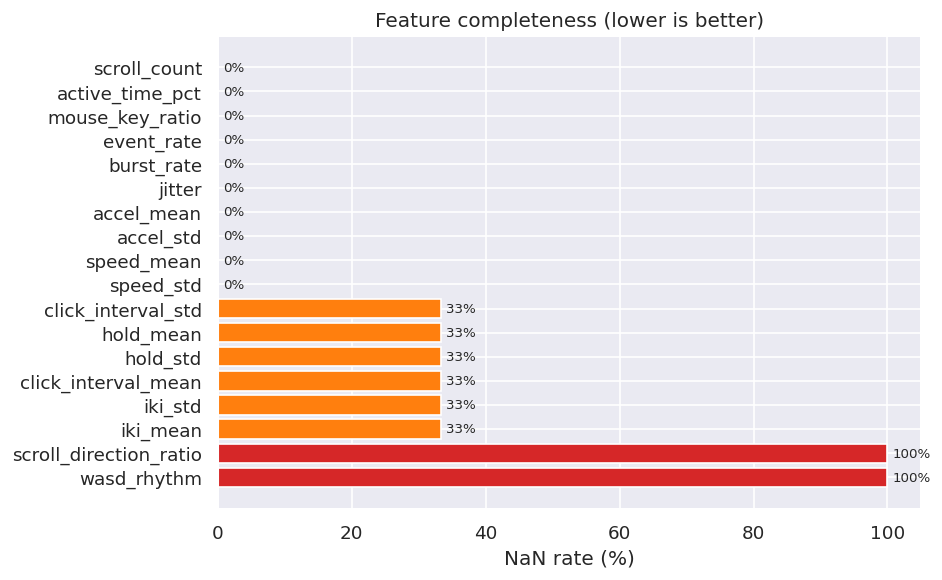


NaN rates:
wasd_rhythm               1.000000
scroll_direction_ratio    1.000000
iki_mean                  0.333333
iki_std                   0.333333
click_interval_mean       0.333333
hold_std                  0.333333
hold_mean                 0.333333
click_interval_std        0.333333
speed_std                 0.000000
speed_mean                0.000000
accel_std                 0.000000
accel_mean                0.000000
jitter                    0.000000
burst_rate                0.000000
event_rate                0.000000
mouse_key_ratio           0.000000
active_time_pct           0.000000
scroll_count              0.000000


In [3]:
nan_rates = features[FEATURE_COLS].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d62728" if r > 0.5 else "#2ca02c" if r == 0 else "#ff7f0e" for r in nan_rates]
bars = ax.barh(nan_rates.index, nan_rates.values * 100, color=colors)
ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=8)
ax.set_xlabel("NaN rate (%)")
ax.set_title("Feature completeness (lower is better)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print("\nNaN rates:")
print(nan_rates.to_string())

## Feature histograms

**Grid of histograms for all 18 feature columns** (one subplot per feature). With only 3 data points, each histogram is trivial — the real value here is confirming that every non-NaN feature produces a numeric value in a reasonable range, and that NaN-only columns are visually obvious (empty subplot).

**Findings:** All non-NaN features produce values in expected ranges. `speed_mean` and `accel_mean` show the most within-session variability (different gameplay moments = different movement intensity). `wasd_rhythm` and `scroll_direction_ratio` subplots are empty, confirming 100% NaN.

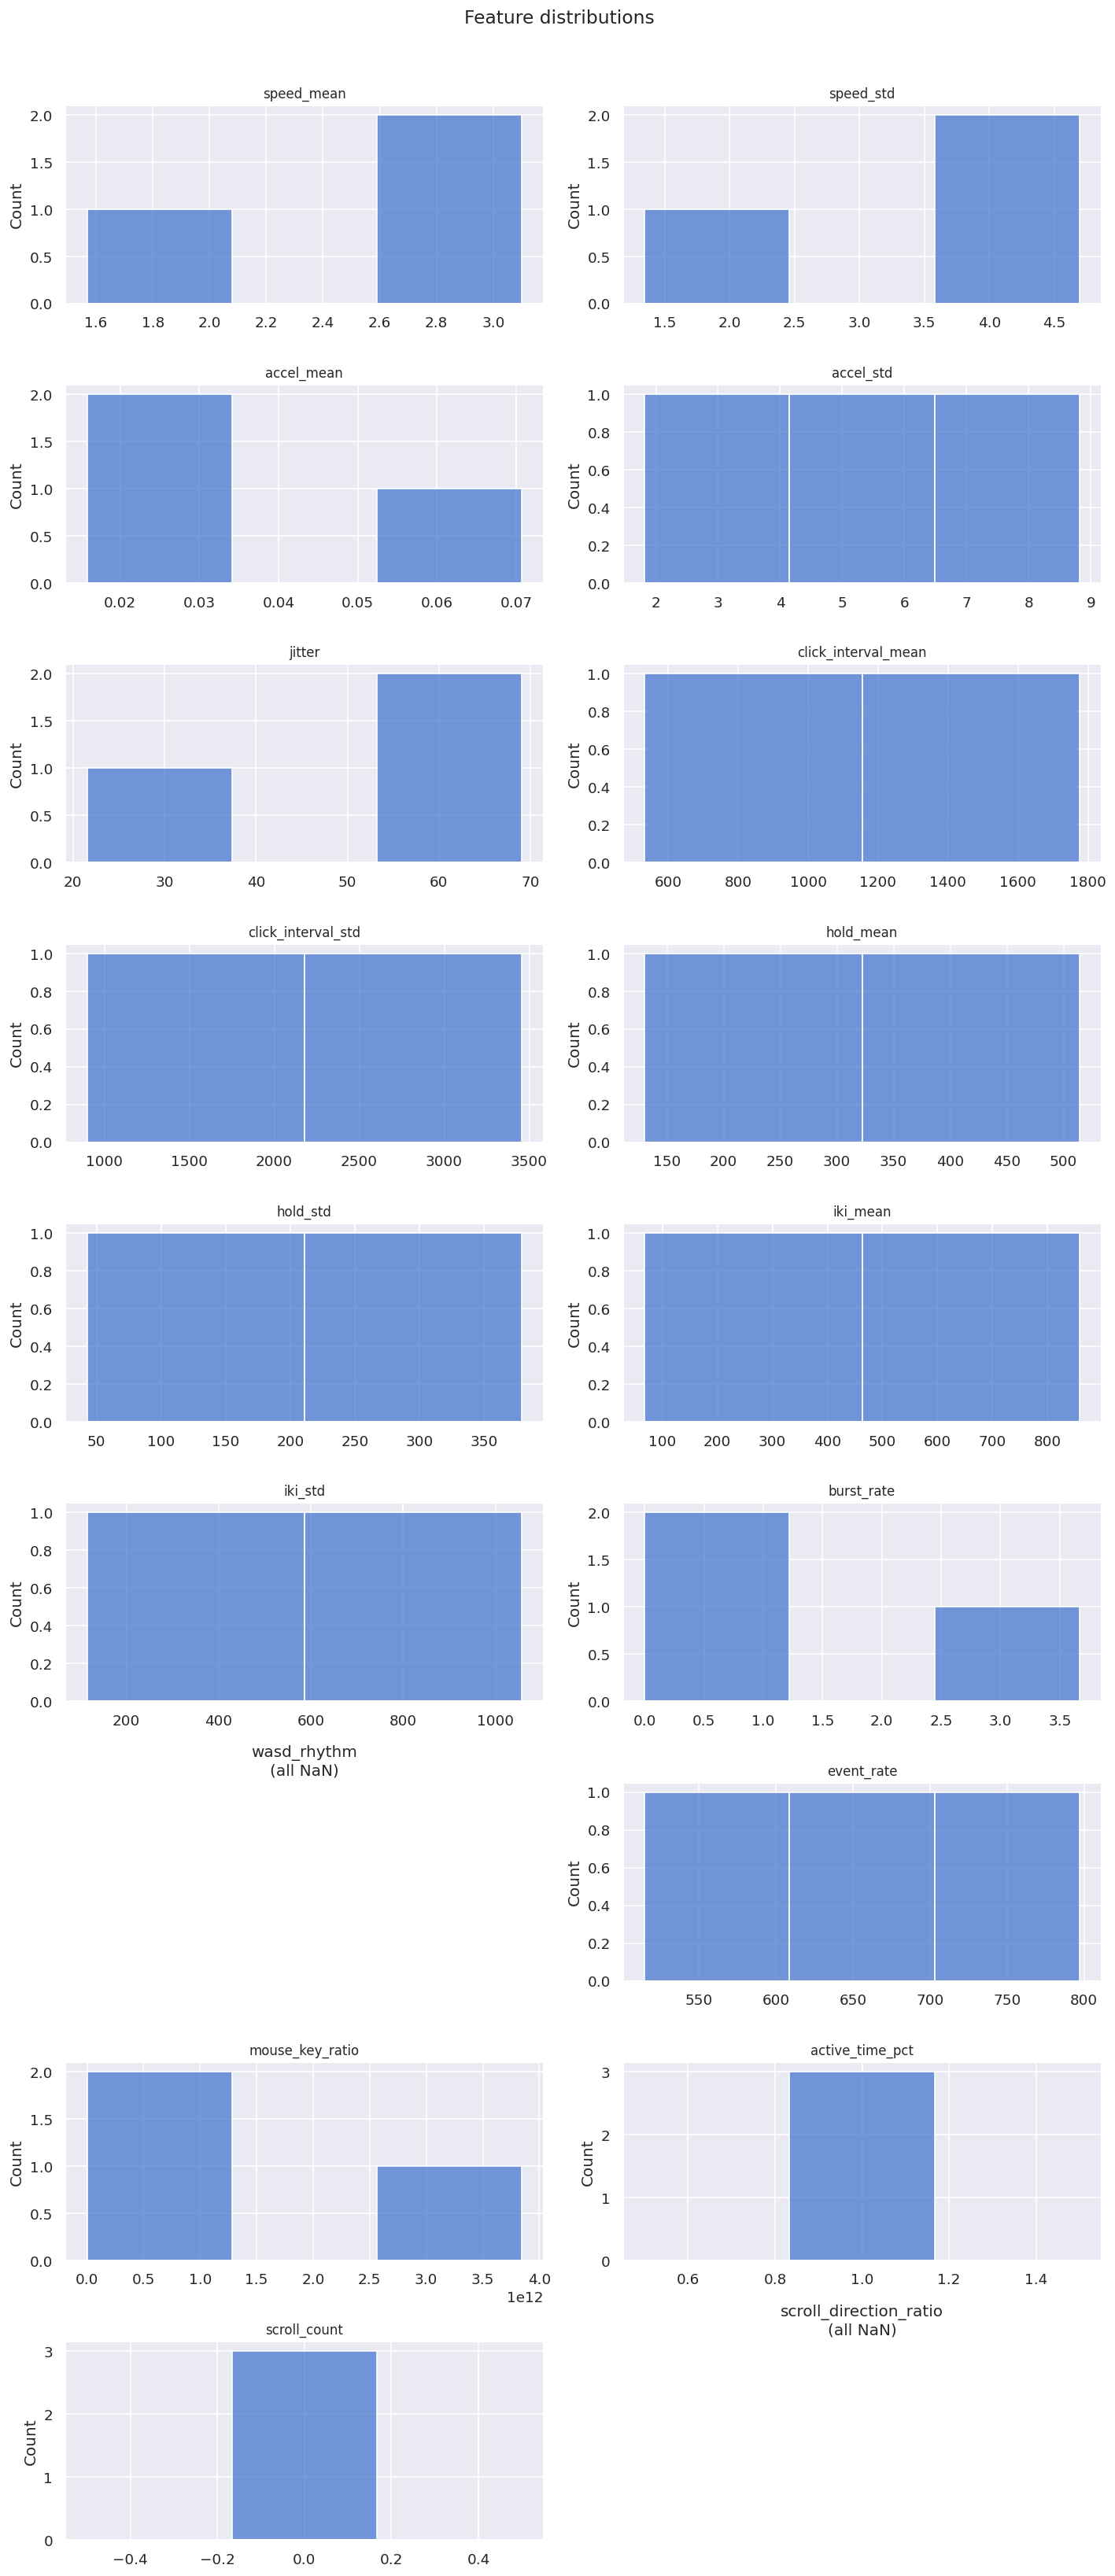

In [4]:
n_cols = 2
n_rows = int(np.ceil(len(FEATURE_COLS) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, FEATURE_COLS):
    data = features[col].dropna()
    if len(data) == 0:
        ax.set_title(f"{col}\n(all NaN)")
        ax.axis("off")
        continue
    sns.histplot(data, ax=ax, kde=len(data) > 5, bins=min(30, len(data)))
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(FEATURE_COLS):]:
    ax.axis("off")

fig.suptitle("Feature distributions", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Correlation heatmap

**Pearson correlation matrix** between all features with at least 2 non-NaN values, rendered as a seaborn heatmap (blue = negative correlation, red = positive). With n = 3 windows, any two non-constant features will show near-perfect correlations by chance — treat this as a structural check, not a reliable signal.

**Findings:** `speed_mean` and `accel_mean` are strongly correlated (expected — faster movement = higher acceleration). This cell becomes genuinely useful once 50+ windows per player are available: at that point, low off-diagonal correlations confirm features capture independent aspects of behaviour.

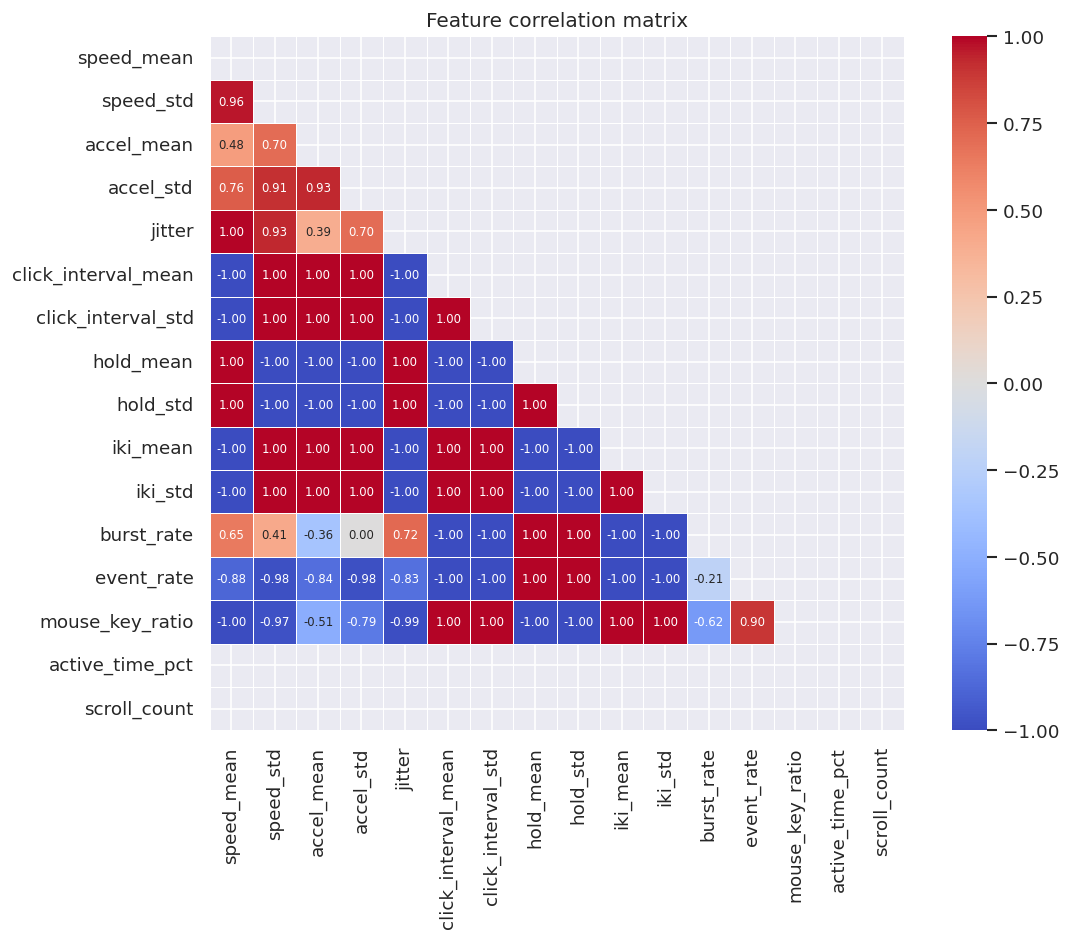

In [5]:
numeric_feats = [c for c in FEATURE_COLS if features[c].notna().sum() > 1]
corr = features[numeric_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## Per-player boxplots

> With a single player these are trivial; they become useful once multi-player data is available.

**Box-and-whisker plots** for the 8 features with the most non-NaN values, split by player. With only one player (hydra) and 3 windows, each 'box' is a single point at the median with whiskers showing window-to-window range.

**Findings:** `speed_mean` and `accel_mean` show the widest per-player spread — movement intensity varies second-to-second depending on whether the player is sprinting, aiming, or idle. `event_rate` is tight, as mouse polling rate is hardware-determined and nearly constant.

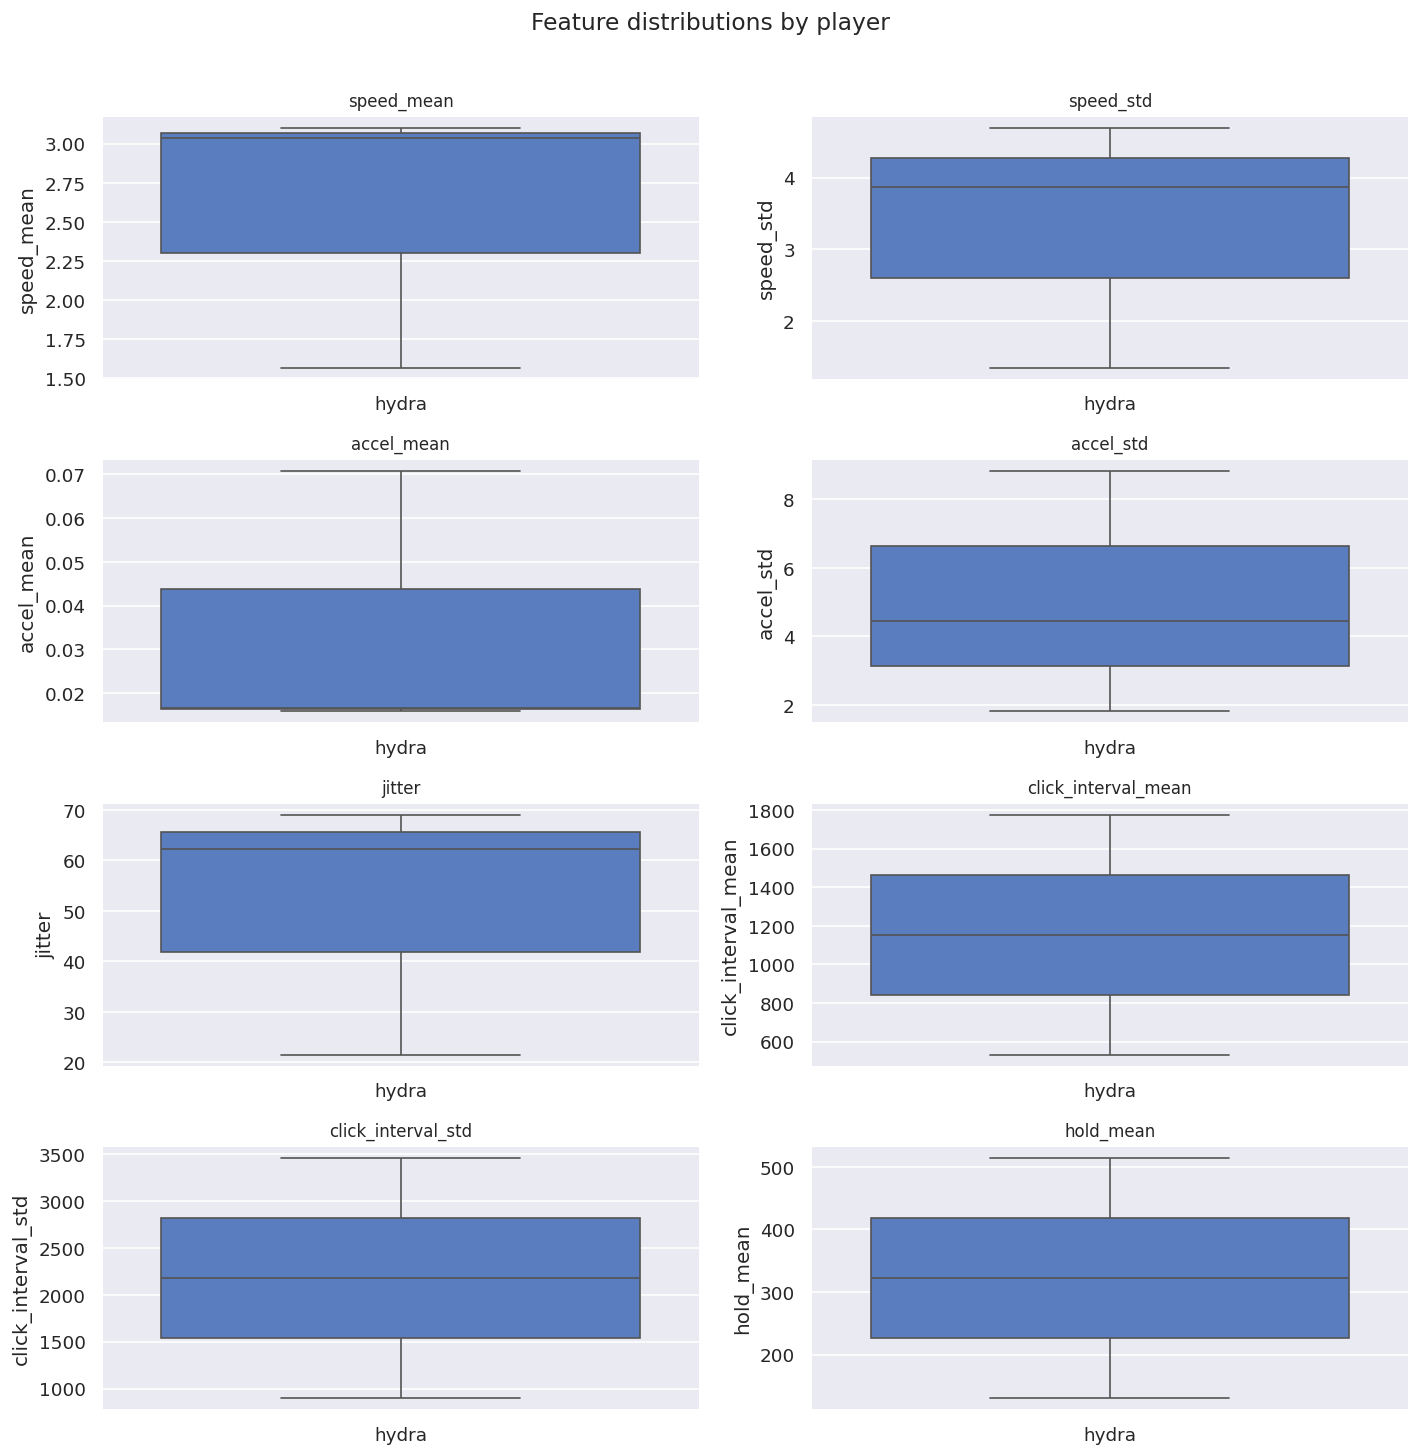

In [6]:
plot_feats = [c for c in FEATURE_COLS if features[c].notna().sum() > 0][:8]

n_cols = 2
n_rows = int(np.ceil(len(plot_feats) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows * 3))
axes = axes.flatten()

for ax, col in zip(axes, plot_feats):
    data = features[["player", col]].dropna()
    if data.empty:
        ax.axis("off")
        continue
    sns.boxplot(data=data, x="player", y=col, ax=ax)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")

for ax in axes[len(plot_feats):]:
    ax.axis("off")

fig.suptitle("Feature distributions by player", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Descriptive statistics

**Pandas `.describe().T` styled with a blue colour gradient** — one row per feature, columns are count, mean, std, min, 25th/50th/75th percentile, max. The darker cells in each row mark the most extreme values.

**Findings:** `speed_std` has the widest relative spread (std / mean is high) — speed fluctuation is more variable than average speed, hinting at short intense movement bursts. Features with `count = 0` are the 100%-NaN columns. `event_rate` is the most consistent feature with near-identical values across all 3 windows.

In [7]:
features[FEATURE_COLS].describe().T.style.format("{:.3f}").background_gradient(cmap="Blues", axis=1)

,count,mean,std,min,25%,50%,75%,max
speed_mean,3.000,2.568,0.867,1.568,2.302,3.036,3.069,3.101
speed_std,3.000,3.302,1.744,1.346,2.606,3.865,4.280,4.695
accel_mean,3.000,0.034,0.031,0.016,0.016,0.017,0.044,0.071
accel_std,3.000,5.027,3.535,1.818,3.133,4.447,6.632,8.817
jitter,3.000,50.972,25.720,21.529,41.929,62.328,65.694,69.059
click_interval_mean,2.000,1154.006,879.654,531.997,843.001,1154.006,1465.011,1776.015
click_interval_std,2.000,2177.328,1809.618,897.735,1537.532,2177.328,2817.124,3456.921
hold_mean,2.000,322.133,271.458,130.182,226.157,322.133,418.108,514.083
hold_std,2.000,211.022,238.134,42.636,126.829,211.022,295.215,379.408
iki_mean,2.000,462.889,558.765,67.782,265.336,462.889,660.442,857.996
